# Анимация детерминированной динамики
§6.1.5, стр. 202–204. В печатном коде ошибочно повторён сканирующий сценарий.
Здесь реализовано текстовое задание: 501 кадр S/I/R на всём интервале 0…100.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("SIRPetri.jl"))
using .SIRPetri
include(srcdir("experiment_support.jl"))

animate_sir

## Траектория с шагом .2

In [2]:
net, u0, _ = build_sir_network(0.3, 0.1)
df_animation = simulate_deterministic(net, u0, (0.0, 100.0); saveat=0.2, rates=[0.3, 0.1])
save_table("sir_animation.csv", df_animation)
first(df_animation, 6)

Row,time,S,I,R
,Float64,Float64,Float64,Float64
1,0.0,990.0,10.0,0.0
2,0.2,-1.57919e-12,981.705,18.2948
3,0.4,4.67514e-11,962.266,37.7339
4,0.6,-8.51923e-12,943.212,56.788
5,0.8,-1.8189e-12,924.535,75.4649
6,1.0,3.61457e-11,906.228,93.7719


## Сохранение и показ GIF

[ Info: Saved animation to /workspace/labs/lab06/image/01-animation.gif


Plots.AnimatedGif("/workspace/labs/lab06/image/01-animation.gif")
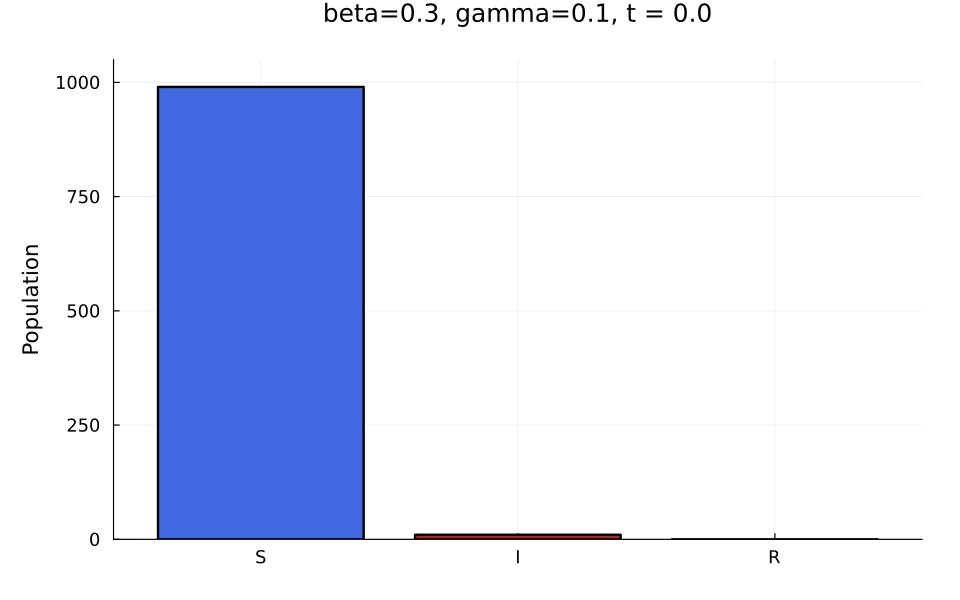

In [3]:
animation = animate_sir(df_animation, "01-animation.gif"; title="beta=0.3, gamma=0.1")
display(animation)

## Опорные состояния для печатного документа

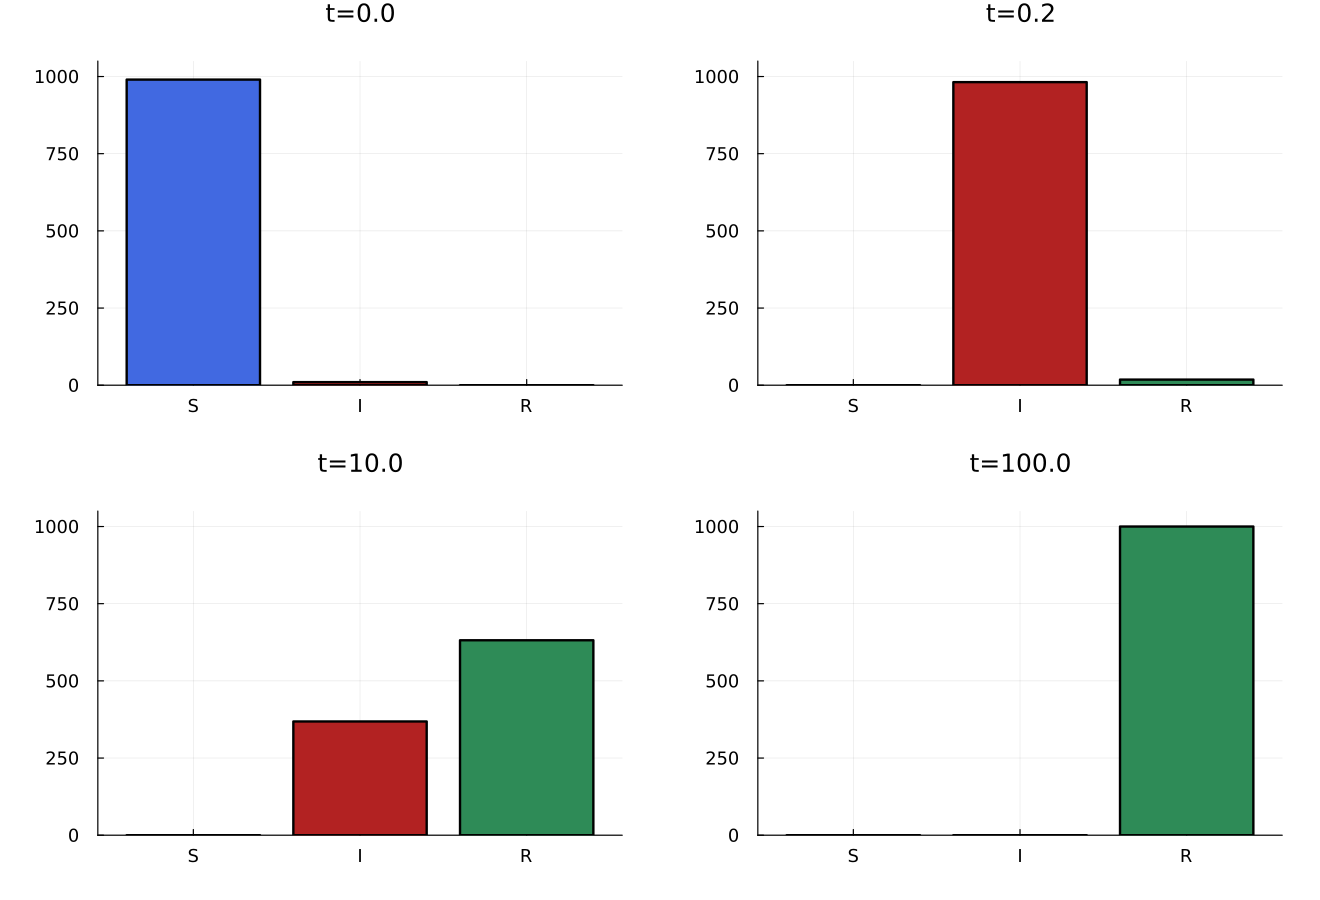

In [4]:
panels = [bar(["S", "I", "R"], [df_animation.S[i], df_animation.I[i], df_animation.R[i]];
    color=[:royalblue, :firebrick, :seagreen], legend=false, ylim=(0,1050),
    title="t=$(df_animation.time[i])") for i in [1,2,51,501]]
p_frames = plot(panels...; layout=(2,2), size=(1100,750))
savefig(p_frames, imagepath("07-plot.png"))
display(p_frames)